In [1]:
import json
import pandas as pd
from datetime import datetime
from collections import deque
import numpy as np

file_path = "../../edge/processed_topic_samples/plc_processed_cnc_toolchange_s01.json"

# JSON 읽기
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# timestamp 변환
for obj in data:
    ts = obj.get("timestamp")
    if ts:
        obj["timestamp"] = datetime.fromisoformat(ts.replace("Z", "+00:00"))

# DataFrame 생성
df = pd.DataFrame(data)

# timestamp 없는 행 제거
df = df[df["timestamp"].notna()].copy()

# 정렬
df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,edgeId,equipmentId,jobId,productId,lotId,eventType,previousState,currentState,previousMode,currentMode,durationSec,alarmCode,deltaTotal,deltaGood,deltaReject
0,2026-03-03 08:00:10+00:00,EDGE_01,CNC_01,JOB_001,BRAKEROTER_A,LOT_01,MODE_TRANSITION,NaN,NaN,SETUP,AUTO,NaN,NaN,NaN,NaN,None
1,2026-03-03 08:00:11+00:00,EDGE_01,Conveyor_01,JOB_001,BRAKEROTER_A,LOT_01,MODE_TRANSITION,NaN,NaN,SETUP,AUTO,NaN,NaN,NaN,NaN,None
2,2026-03-03 08:00:20+00:00,EDGE_01,CNC_01,JOB_001,BRAKEROTER_A,LOT_01,STATE_TRANSITION,IDLE,RUN,NaN,NaN,10.0,NaN,NaN,NaN,None
3,2026-03-03 08:00:21+00:00,EDGE_01,Conveyor_01,JOB_001,BRAKEROTER_A,LOT_01,STATE_TRANSITION,IDLE,RUN,NaN,NaN,10.0,NaN,NaN,NaN,None
4,2026-03-03 08:02:50+00:00,EDGE_01,CNC_01,JOB_001,BRAKEROTER_A,LOT_01,STATE_TRANSITION,RUN,COMPLETE,NaN,NaN,150.0,NaN,NaN,NaN,None


In [2]:
# Line_01 제품 기준 PRODUCTION_COMPLETE 이벤트만 추출
line_events = df[(df["equipmentId"] == "Line_01") 
                 & (df["eventType"] == "PRODUCTION_COMPLETE")].sort_values("timestamp").reset_index(drop=True)


# 최근 5개 제품 Window
# deque -> sliding window 구현에 편리
window = deque(maxlen=5)

In [3]:
features_list = []
max_window_size = 5

for idx, event in line_events.iterrows():
    # window 에 이벤트 추가
    window.append(event)

    
    if len(window) == 5:
        # Feature 계산
        # 1) 생산 속도 Feature (평균 interval, std)
        timestamps = [e["timestamp"] for e in window]
        if len(timestamps) > 1:
            intervals = [(timestamps[i] - timestamps[i-1]).total_seconds() for i in range(1, len(timestamps))]
            production_interval_avg = np.mean(intervals)
            production_interval_std = np.std(intervals)
        else:
            production_interval_avg = None
            production_interval_std = None
        

        # 2) 설비 사이클 Feature (CNC RUN -> COMPLETE 기준)
        cycle_events = df[
            (df["equipmentId"] == "CNC_01") &
            (df["eventType"] == "STATE_TRANSITION") &
            (df["previousState"] == "RUN") &
            (df["currentState"] == 'COMPLETE')
        ]
        # window에 해당하는 cycle_events 선택
        cycle_times = []
        for w in window:
            matches = cycle_events[
                (cycle_events["timestamp"] >= w["timestamp"] - pd.Timedelta(seconds=300))&
                (cycle_events["timestamp"] <= w["timestamp"])
            ]
            cycle_times.extend([c["durationSec"] for _, c in matches.iterrows() if c["durationSec"]])
        if cycle_times:
            cycle_time_avg = np.mean(cycle_times)
            cycle_time_std = np.std(cycle_times)
        else:
            cycle_time_avg = None
            cycle_time_std = None


        # 3) 알람 Feature
        alarm_events = df[
            (df["eventType"] == "ALARM_ON") &
            (df["timestamp"] <= event["timestamp"])
        ]
        alarm_count = len(alarm_events)
        alarm_rate = alarm_count / len(window)

        # 4) 설비 상태 Feature (HOLD/IDLE)
        hold_count = len(df[(df["eventType"] == "STATE_TRANSITION") & (df["currentState"]=="HOLD") & 
                            (df["timestamp"] <= event["timestamp"])])
        idle_count = len(df[(df["eventType"] == "STATE_TRANSITION") & (df["currentState"]=="IDLE") &
                            (df["timestamp"] <= event["timestamp"])])
        
        
        # 5) 작업자 개입 Feature (AUTO -> MANUAL)
        manual_mode_count = len(df[(df["eventType"] == "MODE_TRANSITION") &
                                   (df["previousMode"]=="AUTO") &
                                   (df["currentMode"]=="MANUAL") &
                                   (df["timestamp"] <= event["timestamp"])])
        

        # 6) 품질 Feature
        good_count = sum(1 for w in window if w["deltaGood"] is not None and w["deltaGood"] >0)
        reject_count = sum(1 for w in window if w["deltaReject"] is not None and w["deltaReject"] >0)
        reject_rate = reject_count / len(window)


        # 연속 불량 계산
        reject_streak = 0
        current_streak = 0
        for w in window:
            if w["deltaReject"] is not None and w["deltaReject"] >0:
                current_streak += 1
                reject_streak = max(reject_streak, current_streak)
            else:
                current_streak = 0
        
        feature_record = {
            "timestamp" : event["timestamp"].isoformat(),
            "production_interval_avg": production_interval_avg,
            "production_interval_std": production_interval_std,
            "cycle_time_avg": cycle_time_avg,
            "cycle_time_std": cycle_time_std,
            "alarm_count": alarm_count,
            "alarm_rate": float(alarm_rate),
            "hold_count": hold_count,
            "idle_count": idle_count,
            "manual_mode_count": manual_mode_count,
            "good_count": good_count,
            "reject_count": reject_count,
            "reject_rate": reject_rate,
            "reject_streak": reject_streak
        }
        features_list.append(feature_record)
print(features_list)



[{'timestamp': '2026-03-03T08:20:00+00:00', 'production_interval_avg': np.float64(235.0), 'production_interval_std': np.float64(78.33900688673555), 'cycle_time_avg': np.float64(150.0), 'cycle_time_std': np.float64(0.0), 'alarm_count': 1, 'alarm_rate': 0.2, 'hold_count': 1, 'idle_count': 2, 'manual_mode_count': 1, 'good_count': 5, 'reject_count': 0, 'reject_rate': 0.0, 'reject_streak': 0}, {'timestamp': '2026-03-03T08:22:40+00:00', 'production_interval_avg': np.float64(235.0), 'production_interval_std': np.float64(78.33900688673555), 'cycle_time_avg': np.float64(150.0), 'cycle_time_std': np.float64(0.0), 'alarm_count': 1, 'alarm_rate': 0.2, 'hold_count': 1, 'idle_count': 2, 'manual_mode_count': 1, 'good_count': 5, 'reject_count': 0, 'reject_rate': 0.0, 'reject_streak': 0}, {'timestamp': '2026-03-03T08:25:20+00:00', 'production_interval_avg': np.float64(235.0), 'production_interval_std': np.float64(78.33900688673555), 'cycle_time_avg': np.float64(150.0), 'cycle_time_std': np.float64(0.0)

In [4]:
import json

# JSON 파일로 저장
with open("../../kafka_streams/feature_topic_samples/feature_toolchange_s01.json","w") as f:
    json.dump(features_list, f, ensure_ascii=False, indent=4)


# DataFrame 으로 변환 -> csv로 저장
feature_df = pd.DataFrame(features_list)
feature_df.to_csv("../../kafka_streams/feature_topic_samples/feature_toolchange_s01.csv", index=False)

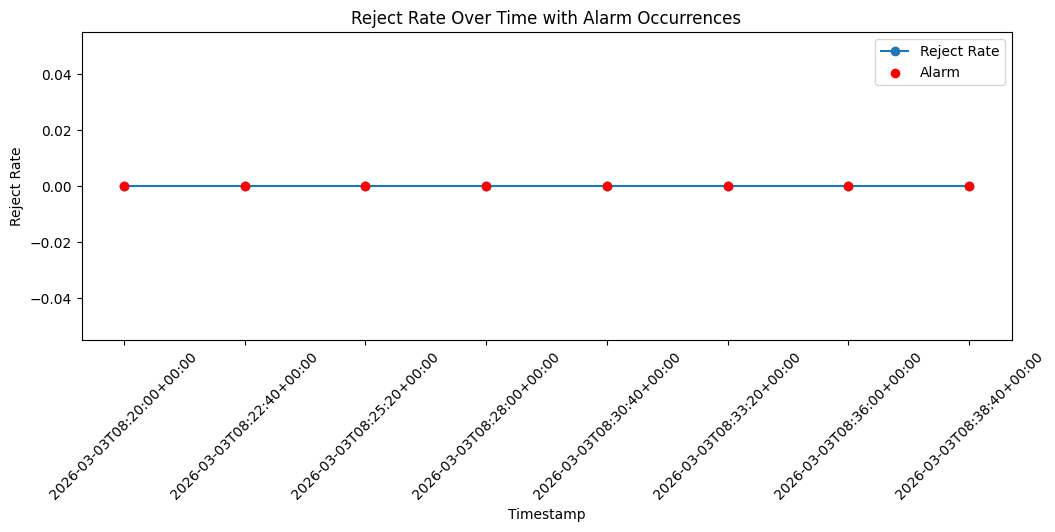

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 예시 feature_df: timestamp, good_count, reject_count, alarm_count
feature_df["total_delta"] = feature_df["good_count"] + feature_df["reject_count"]
feature_df["reject_rate_calc"] = feature_df["reject_count"] / feature_df["total_delta"]
feature_df.loc[feature_df["total_delta"] == 0, "reject_rate_calc"] = None  # 생산 0 제외

plt.figure(figsize=(12,4))
plt.plot(feature_df["timestamp"], feature_df["reject_rate_calc"], label="Reject Rate", marker='o')

# 알람 발생 시점 표시
alarm_times = feature_df.loc[feature_df["alarm_count"] > 0, "timestamp"]
alarm_values = feature_df.loc[feature_df["alarm_count"] > 0, "reject_rate_calc"]
plt.scatter(alarm_times, alarm_values, color='red', label="Alarm", zorder=5)

plt.xticks(rotation=45)
plt.ylabel("Reject Rate")
plt.xlabel("Timestamp")
plt.title("Reject Rate Over Time with Alarm Occurrences")
plt.legend()
plt.show()